In [42]:
import numpy as np
import qiskit as qk
import random
from tqdm import tqdm
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

In [43]:
def count_2q(qc):
    """
    Count the number of 2q

    :param qc: The quantum circuit to count CNOT gates in.
    :return: The number of 2q gates in the circuit.
    """
    count = 0

    for instru in qc.data: # expand into each instruction
        op = instru.operation
        if op.num_qubits == 2: # this is a two qubit gate
            count += 1

    
    return count

In [44]:
def nunu_interaction_pisom(qc, q, alpha, p=[np.pi/2, -np.pi/2, np.pi/4]):
        a, b, c, d = q
        gate = qc
        gate.cx(a, c)
        gate.cx(b, d)
        gate.ry(np.pi/4, a)
        gate.ry(np.pi/4, b)
        gate.cx(c, a)
        gate.cx(d, b)
        gate.ry(-np.pi/4, a)
        gate.ry(-np.pi/4, b)
        gate.rz(-alpha, c)
        gate.rz(-alpha + p[0], d)
        gate.cx(a, c)
        gate.cx(b, d)
        gate.cx(a, b)
        gate.rz(-2 * alpha + p[0], b)
        gate.rz(alpha, c)
        gate.rz(alpha + p[1], d)
        gate.cx(a, b)
        gate.cx(b, c)
        gate.rz(alpha + p[1], c)
        gate.cx(a, c)
        gate.rz(-alpha + p[0], c)
        gate.cx(a, d)
        gate.cx(b, c)
        gate.rz(alpha, d)
        gate.cx(b, d)
        gate.rz(-alpha, d)
        gate.cx(a, d)
        gate.ry(np.pi/4, a)
        gate.ry(np.pi/4, b)
        gate.cx(d, b)
        gate.cx(c, a)
        gate.ry(-np.pi/4, a)
        gate.ry(-np.pi/4, b)
        gate.cx(b, d)
        gate.cx(a, c)


In [45]:
qc = qk.QuantumCircuit(4)
nunu_interaction_pisom(qc, (0, 1, 2, 3), qk.circuit.Parameter('alpha'))

In [ ]:
high = 99999
mval = 0
rel = 0

initial_layout = [0, 1, 2, 3]
# coupling_map = None

for i in tqdm(range(100)):
    # coupling_map = qk.transpiler.CouplingMap.from_ring(10)
    coupling_map = qk.transpiler.CouplingMap.from_line(4)
    tqc = qk.compiler.transpile(qc, optimization_level=3, seed_transpiler=random.randint(0, 10000000), approximation_degree=1, coupling_map=coupling_map, initial_layout=initial_layout)
    oqc = qk.compiler.transpile(qc, optimization_level=0, coupling_map=coupling_map)

    fid = 0
    for par in np.linspace(0, 1, 10):
        a = qk.quantum_info.Operator(tqc.assign_parameters({qc.parameters[0]: par}).to_gate())
        b = qk.quantum_info.Operator(oqc.assign_parameters({qc.parameters[0]: par}).to_gate())
        fid += qk.quantum_info.process_fidelity(a, b)
        rel += np.linalg.norm(a.to_matrix() - b.to_matrix())**2 / np.linalg.norm(a.to_matrix())**2
    fid /= 10
    rel = rel / 10
    
    if count_2q(tqc) <= high and fid > mval:
        print("Circuit with 2q gates: ", count_2q(tqc))
        print("Fidelity: ", fid)
        print("This is obtained on iteration: ", i)
        print("Relative error: ", rel)
        high = count_2q(tqc)
        mval = fid

  3%|▎         | 3/100 [00:00<00:04, 20.67it/s]

Circuit with 2q gates:  18
Fidelity:  0.9999999999999998
This is obtained on iteration:  0
Relative error:  0.0


100%|██████████| 100/100 [00:04<00:00, 20.89it/s]


In [47]:
print(count_2q(tqc))

18


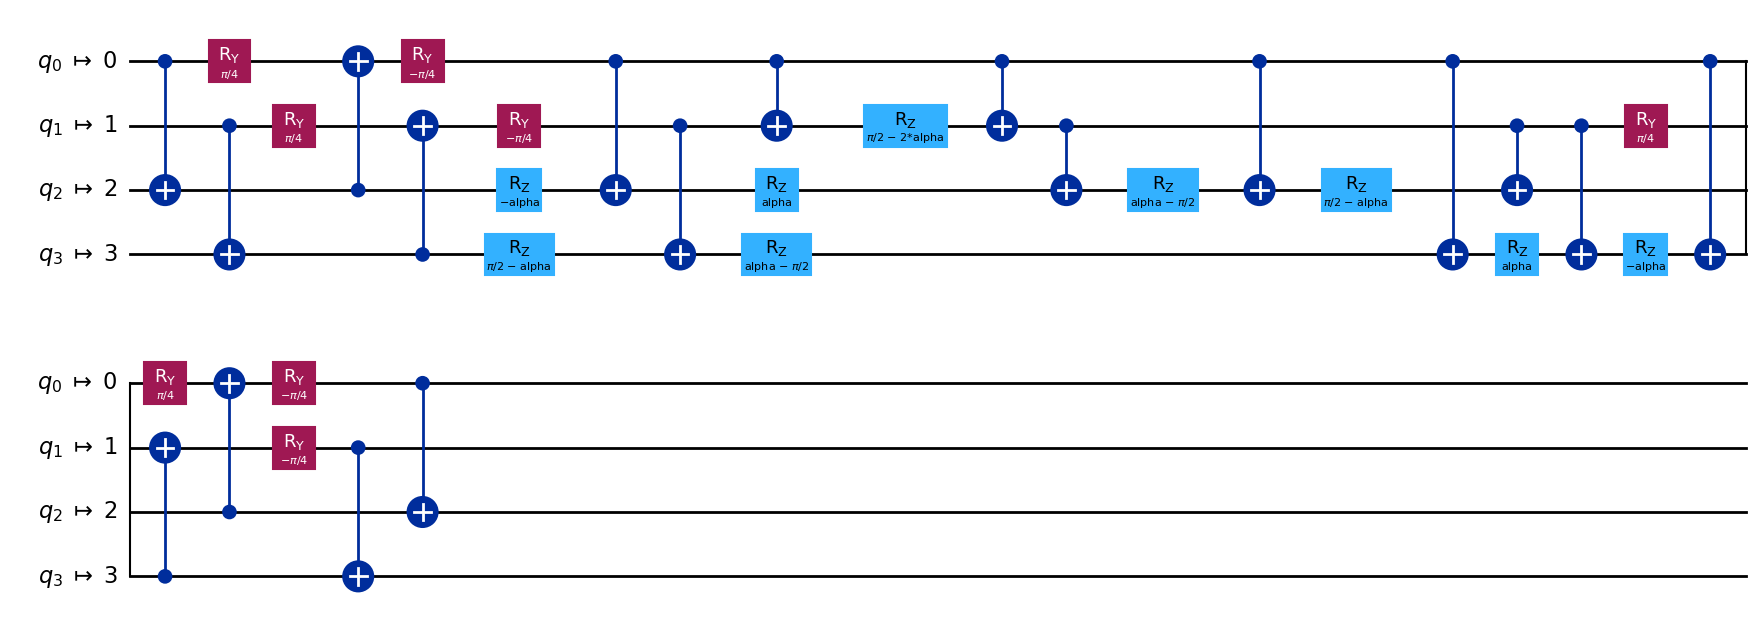

In [48]:
tqc.draw('mpl')

In [49]:
with open('../circuits/nunu_interact_swap.qpy', 'wb') as f:
    qk.qpy.dump(tqc, f)